In [6]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import xgboost as xgb
from  sklearn.metrics import roc_auc_score , roc_curve, classification_report , accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs



In [7]:
np.random.seed(42)

n_samples_1= 25
n_samples_2= 375
center= [(0,0),(2,2)]
cluster_std= [1.5,1.5]

X,y = make_blobs(n_samples= [n_samples_1, n_samples_2],centers= center, cluster_std= cluster_std , random_state=42)


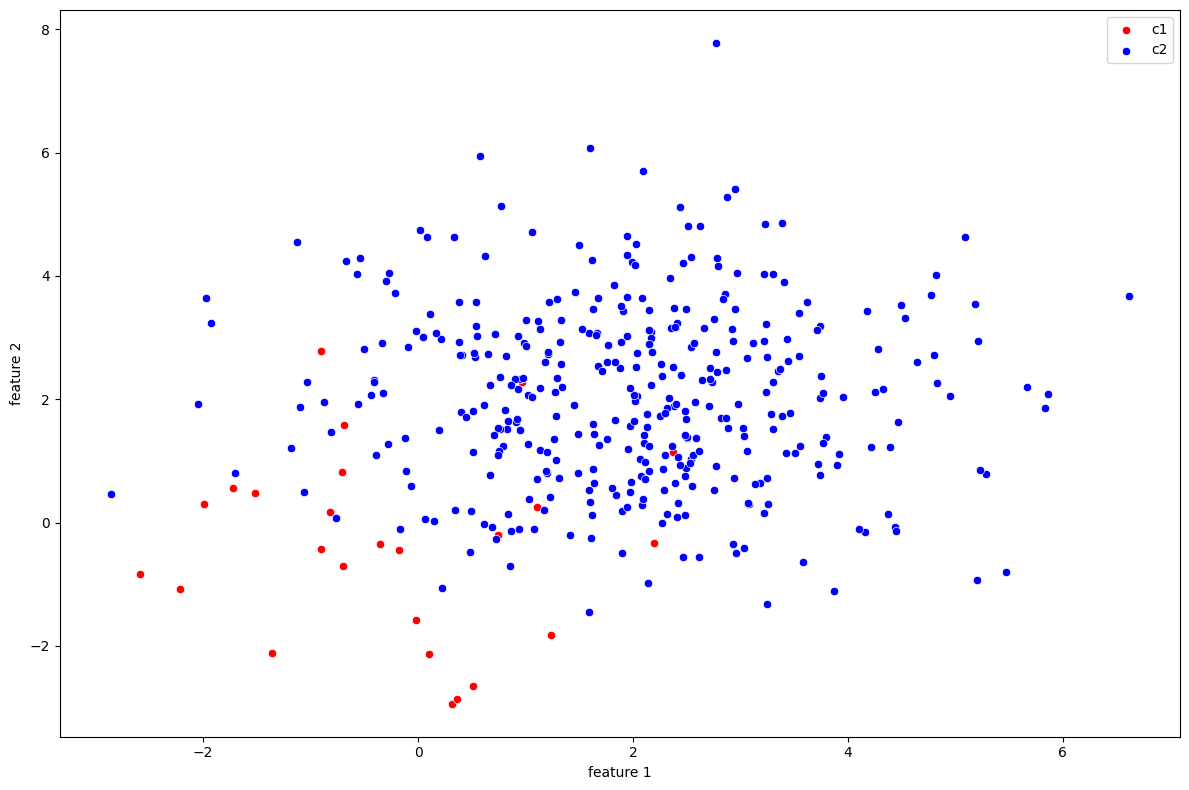

In [8]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=X[y==0][:,0], y=X[y==0][:,1], color='red', label='c1')
sns.scatterplot(x=X[y==1][:,0], y=X[y==1][:,1], color ='blue', label='c2')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.98      0.98      0.98       113

    accuracy                           0.97       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.97      0.97      0.97       120

ROC AUC Score: 0.9292035398230089


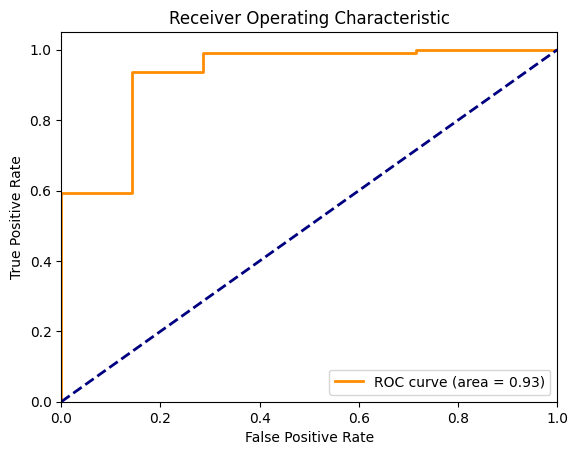

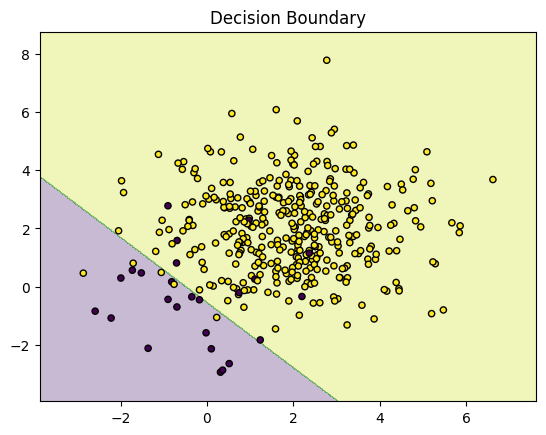

In [27]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train RandomForest classifier
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Predict test set
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()

# Plot decision boundary
plot_decision_boundaries(X, y, classifier)


In [14]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split 
X_train , X_test, y_train , y_test= train_test_split(X,y,test_size= 0.3 , random_state=42)
rbu=  RandomUnderSampler(random_state= 42)
X_resampled , y_resampled = rbu.fit_resample(X_train , y_train)




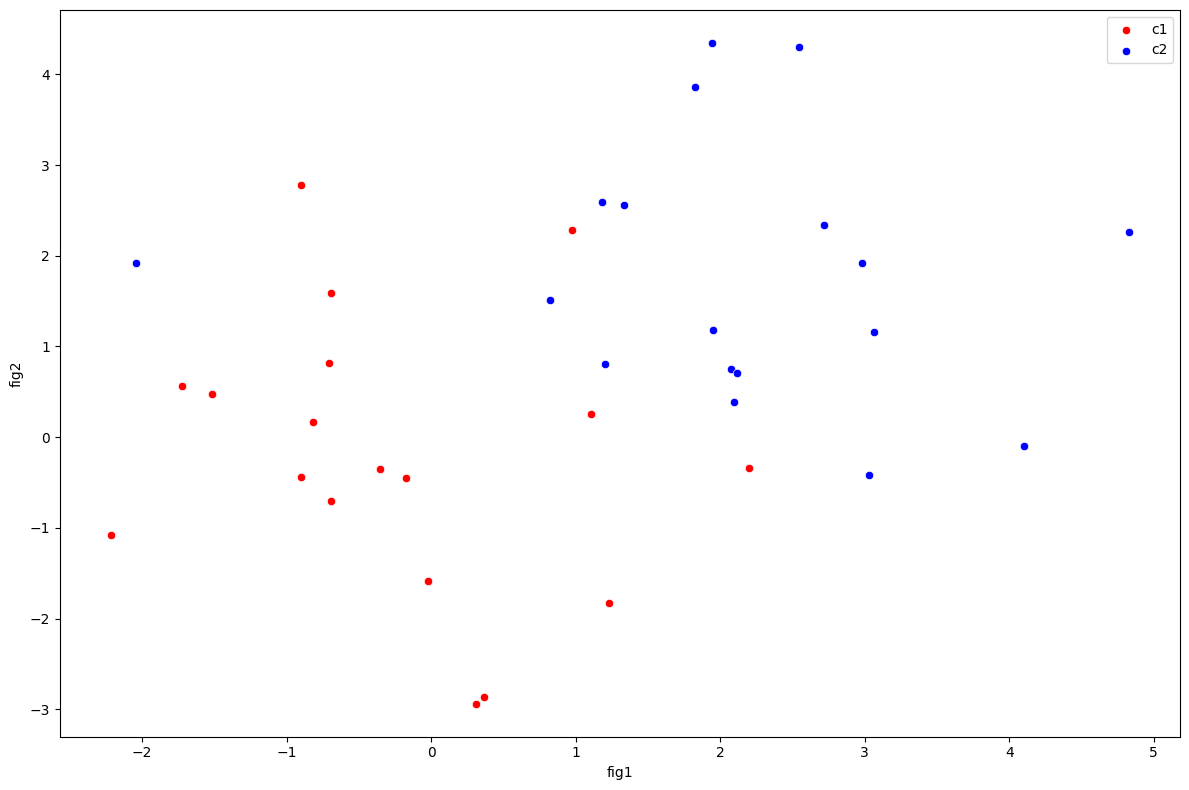

In [17]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=X_resampled[y_resampled==0][:,0], y=X_resampled[y_resampled==0][:,1], color ='red', label= 'c1')
sns.scatterplot(x=X_resampled[y_resampled==1][:,0], y=X_resampled[y_resampled==1][:,1], color ='blue', label= 'c2')
plt.xlabel('fig1')
plt.ylabel('fig2')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
X_train.shape

(280, 2)

In [19]:

X_resampled.shape

(36, 2)

In [22]:
print(pd.Series(y_train).value_counts())

print(pd.Series(y_resampled).value_counts())

1    262
0     18
Name: count, dtype: int64
0    18
1    18
Name: count, dtype: int64


In [29]:
lrs= LogisticRegression()

lrs.fit(X_resampled, y_resampled)
lrs_pred= lrs.predict(X_test)
lrs_curve= lrs.predict_proba(X_test)[:,1]

print(classification_report(y_test, lrs_pred))
print(roc_auc_score(y_test, lrs_pred))

              precision    recall  f1-score   support

           0       0.25      0.86      0.39         7
           1       0.99      0.84      0.91       113

    accuracy                           0.84       120
   macro avg       0.62      0.85      0.65       120
weighted avg       0.95      0.84      0.88       120

0.8489254108723135


In [ ]:
# RANDOM OVERSAMPLING 


In [39]:
from imblearn.over_sampling import RandomOverSampler

ros= RandomOverSampler(random_state= 42)
X_rsampled , y_rsampled=  ros.fit_resample(X_train , y_train)



In [70]:
print(X_train.shape)
print(X_resampled.shape)
print(X_rsampled.shape)
print(X_ssampled.shape)

X_rsampled

(280, 2)
(36, 2)
(524, 2)
(524, 2)


array([[ 2.78291235,  2.44547701],
       [ 0.16680829,  3.06949765],
       [ 1.83685978,  2.60256758],
       ...,
       [-0.69512654, -0.69859463],
       [-0.69512654, -0.69859463],
       [ 0.31329539, -2.93950519]], shape=(524, 2))

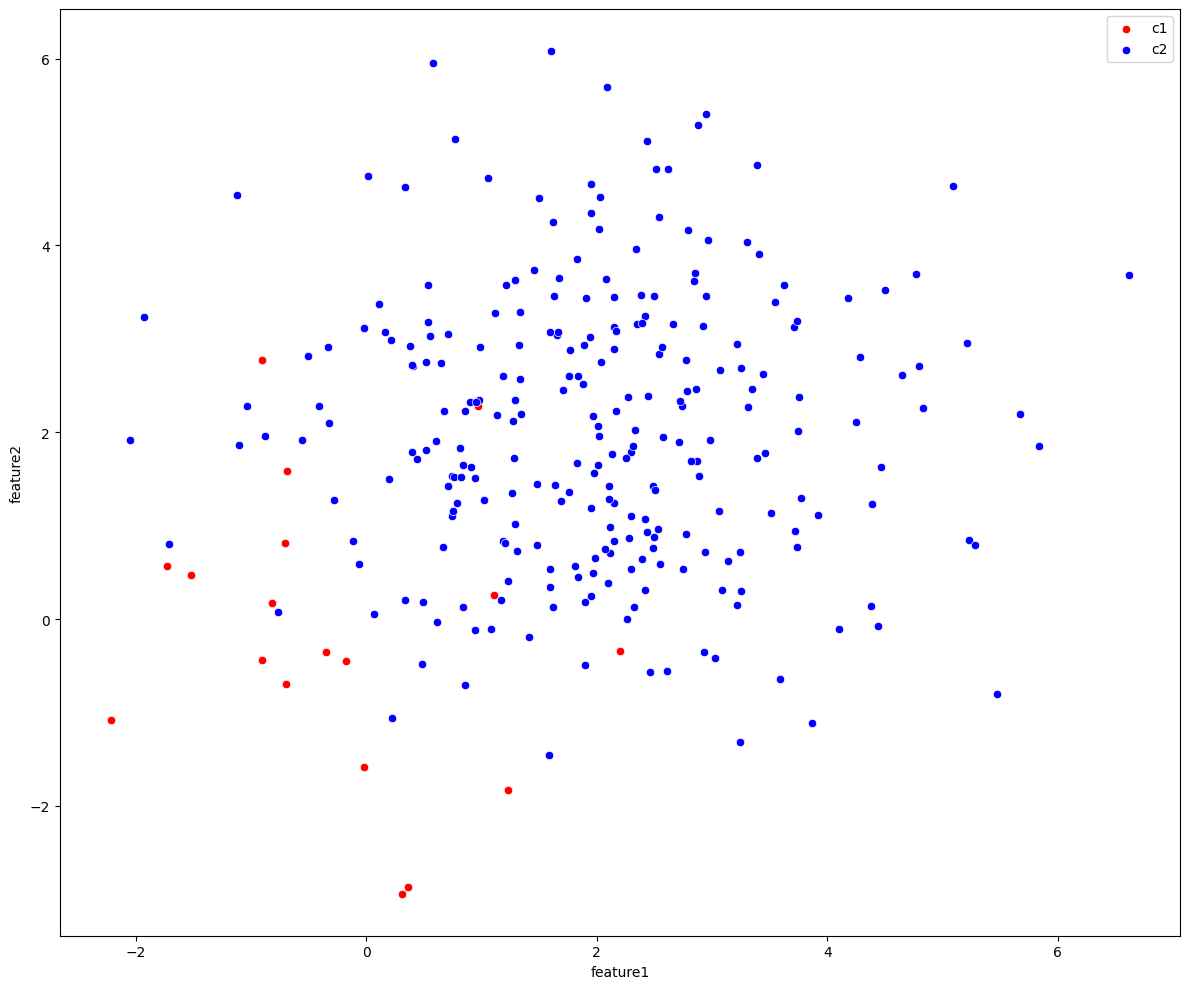

In [47]:
plt.figure(figsize=(12,10))
sns.scatterplot(x=X_rsampled[y_rsampled==0][:,0], y=X_rsampled[y_rsampled==0][:,1], color='red', label='c1')
sns.scatterplot(x=X_rsampled[y_rsampled==1][:,0], y=X_rsampled[y_rsampled==1][:,1], color ='blue', label='c2')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
pd.Series(y_rsampled).value_counts()


1    262
0    262
Name: count, dtype: int64

Classification Report (With Over Sampling):
              precision    recall  f1-score   support

           0       0.25      0.86      0.39         7
           1       0.99      0.84      0.91       113

    accuracy                           0.84       120
   macro avg       0.62      0.85      0.65       120
weighted avg       0.95      0.84      0.88       120

ROC AUC Score (With Over Sampling): 0.9279393173198482


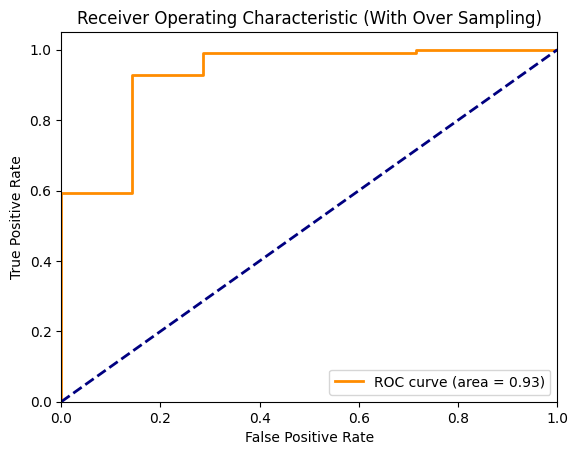

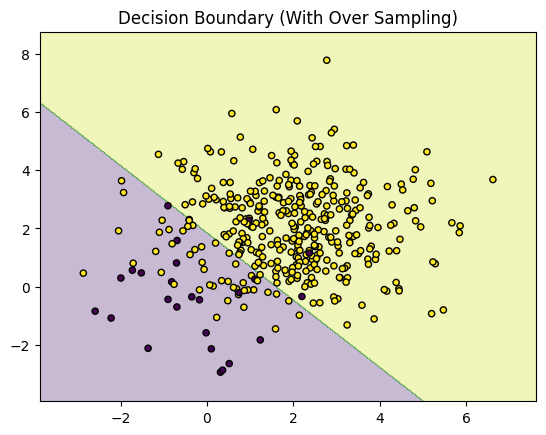

In [50]:
# Initialize and train RandomForest classifier on resampled data
classifier_ros = LogisticRegression()
classifier_ros.fit(X_resampled, y_resampled)

# Predict test set
y_pred_ros = classifier_ros.predict(X_test)
y_proba_ros = classifier_ros.predict_proba(X_test)[:, 1]

# Print classification report for resampled data
print("Classification Report (With Over Sampling):")
print(classification_report(y_test, y_pred_ros))

# Print ROC AUC Score for resampled data
print("ROC AUC Score (With Over Sampling):", roc_auc_score(y_test, y_proba_ros))

# Plotting ROC AUC Curve for resampled data
fpr_ros, tpr_ros, _ = roc_curve(y_test, y_proba_ros)
plt.figure()
plt.plot(fpr_ros, tpr_ros, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_ros))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With Over Sampling)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for resampled data
def plot_decision_boundaries_ros(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With Over Sampling)")
    plt.show()

# Plot decision boundary for resampled data
plot_decision_boundaries_ros(X, y, classifier_ros)


In [53]:
from imblearn.over_sampling import SMOTE

X_train,X_test,y_train ,y_test = train_test_split(X,y, test_size=0.3, random_state=42)



smote = SMOTE(random_state=42)
X_ssampled , y_sampled= smote.fit_resample(X_train , y_train)

X_ssampled

array([[ 2.78291235,  2.44547701],
       [ 0.16680829,  3.06949765],
       [ 1.83685978,  2.60256758],
       ...,
       [ 1.54792085, -0.70456274],
       [ 1.36047611, -0.34278623],
       [-1.58711516,  0.50155695]], shape=(524, 2))

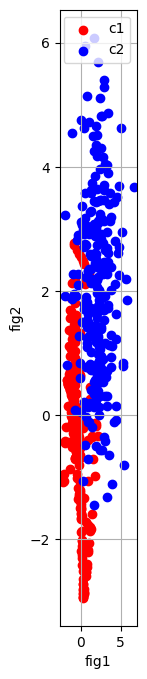

In [69]:
plt.figure(figsize= (1,8))
plt.scatter(x=X_ssampled[y_sampled==0][:,0], y=X_ssampled[y_sampled==0][:,1], color='red', label='c1')
plt.scatter(x=X_ssampled[y_sampled==1][:,0], y=X_ssampled[y_sampled==1][:,1], color='blue', label='c2')
plt.xlabel('fig1')
plt.ylabel('fig2')
plt.legend()
plt.grid(True)

plt.show()


In [71]:
pd.Series(y_sampled).value_counts()

1    262
0    262
Name: count, dtype: int64

In [100]:
from sklearn.metrics import confusion_matrix
lr3= LogisticRegression()
lr3.fit(X_ssampled,  y_sampled)
lr3_pred= lr3.predict(X_test)
lr3_prob= lr3.predict_proba(X_test)[:, 1]

lr3_pred
print(accuracy_score(y_test, lr3_pred))
print(roc_auc_score(y_test , lr3_pred))




# print(lr3_prob)
print(classification_report(y_test, lr3_pred))
print(classification_report(y_test, y_pred_ros))
print(classification_report(y_test, lrs_pred))
print(classification_report(y_test, y_pred))
# print(classification_report(y_test, lr3_pred))
cm= confusion_matrix(y_test, lr3_pred)

# cm3= pd.DataFrame(cm ,index= ['0','1'], columns=['O prediction','1 prediction'])
# print(cm3)
# lr3_pred
# X_ssampled

0.8833333333333333
0.8710493046776234
              precision    recall  f1-score   support

           0       0.32      0.86      0.46         7
           1       0.99      0.88      0.93       113

    accuracy                           0.88       120
   macro avg       0.65      0.87      0.70       120
weighted avg       0.95      0.88      0.91       120

              precision    recall  f1-score   support

           0       0.25      0.86      0.39         7
           1       0.99      0.84      0.91       113

    accuracy                           0.84       120
   macro avg       0.62      0.85      0.65       120
weighted avg       0.95      0.84      0.88       120

              precision    recall  f1-score   support

           0       0.25      0.86      0.39         7
           1       0.99      0.84      0.91       113

    accuracy                           0.84       120
   macro avg       0.62      0.85      0.65       120
weighted avg       0.95      0.84   

Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       0.20      0.75      0.32         4
           1       0.98      0.84      0.91        76

    accuracy                           0.84        80
   macro avg       0.59      0.80      0.61        80
weighted avg       0.95      0.84      0.88        80

ROC AUC Score (With SMOTE): 0.78125


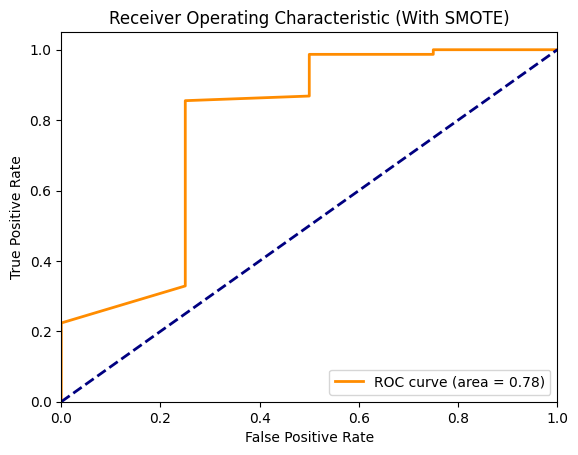

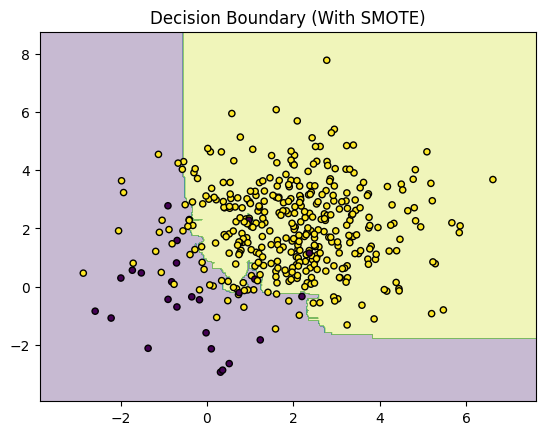

In [109]:
from imblearn.ensemble import BalancedRandomForestClassifier

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying SMOTE
classifier = BalancedRandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

# Predict test set
y_pred_brf = classifier.predict(X_test)
y_proba_brf = classifier.predict_proba(X_test)[:, 1]

# Print classification report for SMOTE data
print("Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred_brf))

# Print ROC AUC Score for SMOTE data
print("ROC AUC Score (With SMOTE):", roc_auc_score(y_test, y_proba_brf))

# Plotting ROC AUC Curve for SMOTE data
fpr_brf, tpr_brf, _ = roc_curve(y_test, y_proba_brf)
plt.figure()
plt.plot(fpr_brf, tpr_brf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba_brf))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (With SMOTE)')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries for SMOTE data
def plot_decision_boundaries_smote(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary (With SMOTE)")
    plt.show()

# Plot decision boundary for SMOTE data
plot_decision_boundaries_smote(X, y, classifier)

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.86      0.31         7
           1       0.99      0.77      0.87       113

    accuracy                           0.78       120
   macro avg       0.59      0.81      0.59       120
weighted avg       0.94      0.78      0.83       120

ROC AUC Score: 0.8786346396965865


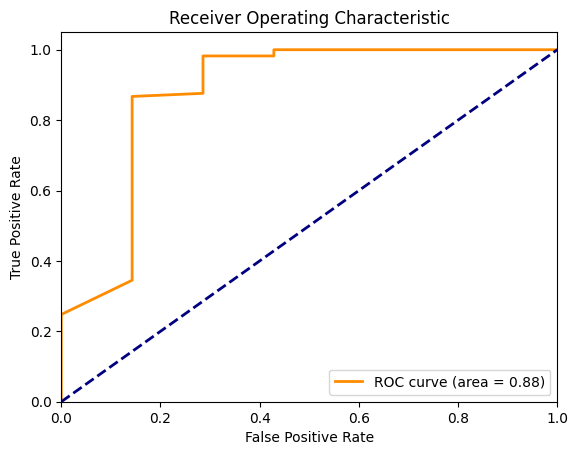

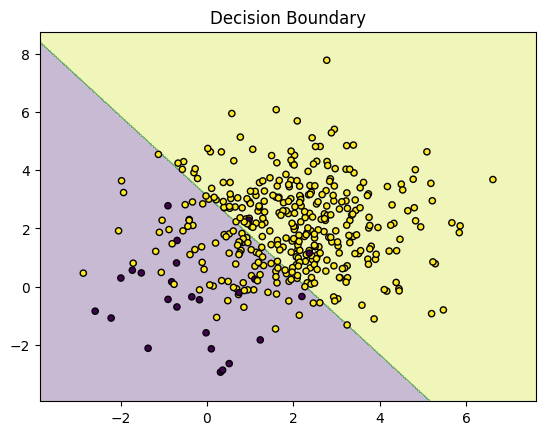

In [110]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a logistic regression model with class weights
model = LogisticRegression(class_weight={0:50,1:1}, solver='liblinear')

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))


# Print ROC AUC Score
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()

# Plot decision boundary
plot_decision_boundaries(X, y, model)



C:\Users\Kunal\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:553: UserWarning: [22:44:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "silent" } are not used.

  return func(**kwargs)


Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.57      0.27         7
           1       0.97      0.83      0.90       113

    accuracy                           0.82       120
   macro avg       0.57      0.70      0.58       120
weighted avg       0.92      0.82      0.86       120

ROC AUC Score: 0.7357774968394437


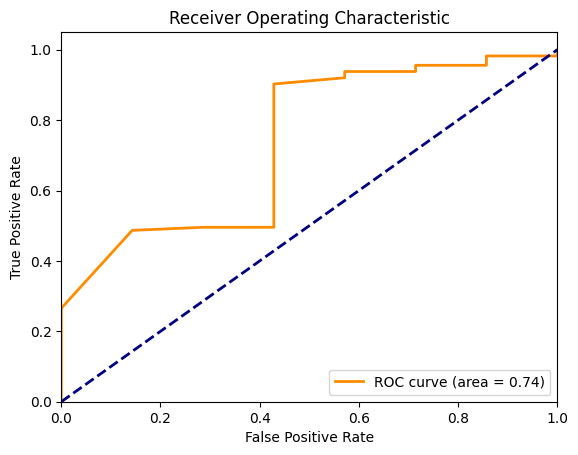

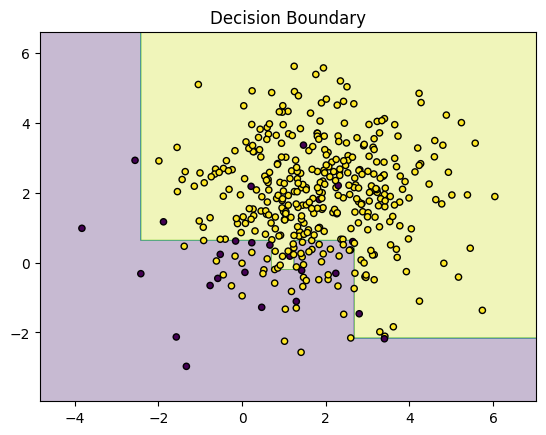

In [111]:
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

# Generate imbalanced dataset
n_samples_1 = 25  # Number of samples in class 1
n_samples_2 = 375  # Number of samples in class 2
centers = [(0, 0), (2, 2)]  # Centers of each cluster
cluster_std = [1.5, 1.5]  # Standard deviation of each cluster

X, y = make_blobs(n_samples=[n_samples_1, n_samples_2],
                  centers=centers,
                  cluster_std=cluster_std,
                  random_state=0)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def custom_loss(preds, dtrain):
    labels = dtrain.get_label()
    preds = 1.0 / (1.0 + np.exp(-preds))  # Convert to probability

    # Define penalties
    false_positive_penalty = 10
    false_negative_penalty = 1.0

    grad = (preds - labels) * ((labels == 1) * false_negative_penalty + (labels == 0) * false_positive_penalty)
    hess = preds * (1 - preds) * ((labels == 1) * false_negative_penalty + (labels == 0) * false_positive_penalty)
    return grad, hess

# Convert to DMatrix object
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set up parameters
params = {
    'max_depth': 3,
    'eta': 0.1,
    'silent': 1,
}

# Train the model
bst = xgb.train(params, dtrain, num_boost_round=10, obj=custom_loss)

# Predict test set
y_pred = np.where(bst.predict(dtest) > 0.5, 1, 0)
y_proba = bst.predict(dtest)  # Probability predictions

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print ROC AUC Score
auc_score = roc_auc_score(y_test, y_proba)
print("ROC AUC Score:", auc_score)

# Plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

def plot_decision_boundaries(X, y, model):
    plot_step = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(xgb.DMatrix(np.c_[xx.ravel(), yy.ravel()]))
    Z = np.where(Z > 0.5, 1, 0).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()

# Plot decision boundary
plot_decision_boundaries(X, y, bst)
